# AML Assignment 2: From Trees to Neural Networks

**Chosen Dataset:** Home Credit Default Risk Dataset

**Task:** Predict whether an applicant will repay a loan, using a wide range of application, credit, and behavioral data.

**Link:** https://www.kaggle.com/c/home-credit-default-risk

### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier

from xgboost import plot_importance

### Load Data

In [2]:
# load locally
df = pd.read_csv('application_train.csv')

In [3]:
df_test = pd.read_csv('application_test.csv')

### Learning the data

In [4]:
# columns
print("DATA COLUMN NAMES:")
for i, col in enumerate(df.columns):
    print(i, col)

DATA COLUMN NAMES:
0 SK_ID_CURR
1 TARGET
2 NAME_CONTRACT_TYPE
3 CODE_GENDER
4 FLAG_OWN_CAR
5 FLAG_OWN_REALTY
6 CNT_CHILDREN
7 AMT_INCOME_TOTAL
8 AMT_CREDIT
9 AMT_ANNUITY
10 AMT_GOODS_PRICE
11 NAME_TYPE_SUITE
12 NAME_INCOME_TYPE
13 NAME_EDUCATION_TYPE
14 NAME_FAMILY_STATUS
15 NAME_HOUSING_TYPE
16 REGION_POPULATION_RELATIVE
17 DAYS_BIRTH
18 DAYS_EMPLOYED
19 DAYS_REGISTRATION
20 DAYS_ID_PUBLISH
21 OWN_CAR_AGE
22 FLAG_MOBIL
23 FLAG_EMP_PHONE
24 FLAG_WORK_PHONE
25 FLAG_CONT_MOBILE
26 FLAG_PHONE
27 FLAG_EMAIL
28 OCCUPATION_TYPE
29 CNT_FAM_MEMBERS
30 REGION_RATING_CLIENT
31 REGION_RATING_CLIENT_W_CITY
32 WEEKDAY_APPR_PROCESS_START
33 HOUR_APPR_PROCESS_START
34 REG_REGION_NOT_LIVE_REGION
35 REG_REGION_NOT_WORK_REGION
36 LIVE_REGION_NOT_WORK_REGION
37 REG_CITY_NOT_LIVE_CITY
38 REG_CITY_NOT_WORK_CITY
39 LIVE_CITY_NOT_WORK_CITY
40 ORGANIZATION_TYPE
41 EXT_SOURCE_1
42 EXT_SOURCE_2
43 EXT_SOURCE_3
44 APARTMENTS_AVG
45 BASEMENTAREA_AVG
46 YEARS_BEGINEXPLUATATION_AVG
47 YEARS_BUILD_AVG
48 COMMONAREA_

In [5]:
# number of rows
print(len(df))

279516


### Data Cleaning

Missing Values:

In [6]:
# same missing value counter I used in A1

missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'total_count': df.count(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})

pd.set_option('display.max_rows', None)
print(missing)

                              missing_count  total_count  missing_%
SK_ID_CURR                                0       279516       0.00
TARGET                                    0       279516       0.00
NAME_CONTRACT_TYPE                        0       279516       0.00
CODE_GENDER                               0       279516       0.00
FLAG_OWN_CAR                              0       279516       0.00
FLAG_OWN_REALTY                           0       279516       0.00
CNT_CHILDREN                              0       279516       0.00
AMT_INCOME_TOTAL                          0       279516       0.00
AMT_CREDIT                                0       279516       0.00
AMT_ANNUITY                              13       279503       0.00
AMT_GOODS_PRICE                         250       279266       0.09
NAME_TYPE_SUITE                        1167       278349       0.42
NAME_INCOME_TYPE                          1       279515       0.00
NAME_EDUCATION_TYPE                       1     

In [7]:
# columns missing more than 50% of values

threshold = 50

missing_50 = missing[missing['missing_%'] > threshold].index.tolist()

print(f"COLUMNS MISSING >50% OF VALUES:")
for col in missing_50:
  print(f" {col} ({missing.loc[col, 'missing_%']}%)")

COLUMNS MISSING >50% OF VALUES:
 OWN_CAR_AGE (66.01%)
 EXT_SOURCE_1 (56.37%)
 APARTMENTS_AVG (50.77%)
 BASEMENTAREA_AVG (58.55%)
 YEARS_BUILD_AVG (66.51%)
 COMMONAREA_AVG (69.88%)
 ELEVATORS_AVG (53.31%)
 ENTRANCES_AVG (50.36%)
 FLOORSMIN_AVG (67.87%)
 LANDAREA_AVG (59.41%)
 LIVINGAPARTMENTS_AVG (68.37%)
 LIVINGAREA_AVG (50.21%)
 NONLIVINGAPARTMENTS_AVG (69.44%)
 NONLIVINGAREA_AVG (55.19%)
 APARTMENTS_MODE (50.77%)
 BASEMENTAREA_MODE (58.55%)
 YEARS_BUILD_MODE (66.51%)
 COMMONAREA_MODE (69.88%)
 ELEVATORS_MODE (53.31%)
 ENTRANCES_MODE (50.36%)
 FLOORSMIN_MODE (67.87%)
 LANDAREA_MODE (59.41%)
 LIVINGAPARTMENTS_MODE (68.37%)
 LIVINGAREA_MODE (50.21%)
 NONLIVINGAPARTMENTS_MODE (69.44%)
 NONLIVINGAREA_MODE (55.19%)
 APARTMENTS_MEDI (50.77%)
 BASEMENTAREA_MEDI (58.55%)
 YEARS_BUILD_MEDI (66.51%)
 COMMONAREA_MEDI (69.88%)
 ELEVATORS_MEDI (53.31%)
 ENTRANCES_MEDI (50.36%)
 FLOORSMIN_MEDI (67.87%)
 LANDAREA_MEDI (59.41%)
 LIVINGAPARTMENTS_MEDI (68.37%)
 LIVINGAREA_MEDI (50.21%)
 NONLIVINGAPART

In [8]:
# drop columns with _AVG or _MODE

cols_to_drop = [col for col in df.columns if '_AVG' in col or '_MODE' in col]

In [9]:
# drop ID column since it's not a feature

cols_to_drop += ['SK_ID_CURR']

In [10]:
df.drop(columns=cols_to_drop, inplace=True)

print(f"Total dropped: {len(cols_to_drop)}")

print(f"Remaining columns: {len(df.columns)}")

Total dropped: 34
Remaining columns: 88


In [11]:
print("UPDATED DATA COLUMN NAMES:")
for i, col in enumerate(df.columns):
    print(i, col)

UPDATED DATA COLUMN NAMES:
0 TARGET
1 NAME_CONTRACT_TYPE
2 CODE_GENDER
3 FLAG_OWN_CAR
4 FLAG_OWN_REALTY
5 CNT_CHILDREN
6 AMT_INCOME_TOTAL
7 AMT_CREDIT
8 AMT_ANNUITY
9 AMT_GOODS_PRICE
10 NAME_TYPE_SUITE
11 NAME_INCOME_TYPE
12 NAME_EDUCATION_TYPE
13 NAME_FAMILY_STATUS
14 NAME_HOUSING_TYPE
15 REGION_POPULATION_RELATIVE
16 DAYS_BIRTH
17 DAYS_EMPLOYED
18 DAYS_REGISTRATION
19 DAYS_ID_PUBLISH
20 OWN_CAR_AGE
21 FLAG_MOBIL
22 FLAG_EMP_PHONE
23 FLAG_WORK_PHONE
24 FLAG_CONT_MOBILE
25 FLAG_PHONE
26 FLAG_EMAIL
27 OCCUPATION_TYPE
28 CNT_FAM_MEMBERS
29 REGION_RATING_CLIENT
30 REGION_RATING_CLIENT_W_CITY
31 WEEKDAY_APPR_PROCESS_START
32 HOUR_APPR_PROCESS_START
33 REG_REGION_NOT_LIVE_REGION
34 REG_REGION_NOT_WORK_REGION
35 LIVE_REGION_NOT_WORK_REGION
36 REG_CITY_NOT_LIVE_CITY
37 REG_CITY_NOT_WORK_CITY
38 LIVE_CITY_NOT_WORK_CITY
39 ORGANIZATION_TYPE
40 EXT_SOURCE_1
41 EXT_SOURCE_2
42 EXT_SOURCE_3
43 APARTMENTS_MEDI
44 BASEMENTAREA_MEDI
45 YEARS_BEGINEXPLUATATION_MEDI
46 YEARS_BUILD_MEDI
47 COMMONAREA_ME

### Split Data

In [12]:
# seperate variables from target for model training
X = df.drop(columns='TARGET')
y = df['TARGET']

In [13]:
# 70/15/15 split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Train class distribution: {dict(y_train.value_counts())}')

Train : 195661 samples
Val   : 41927 samples
Test  : 41928 samples
Train class distribution: {0: np.int64(179842), 1: np.int64(15819)}


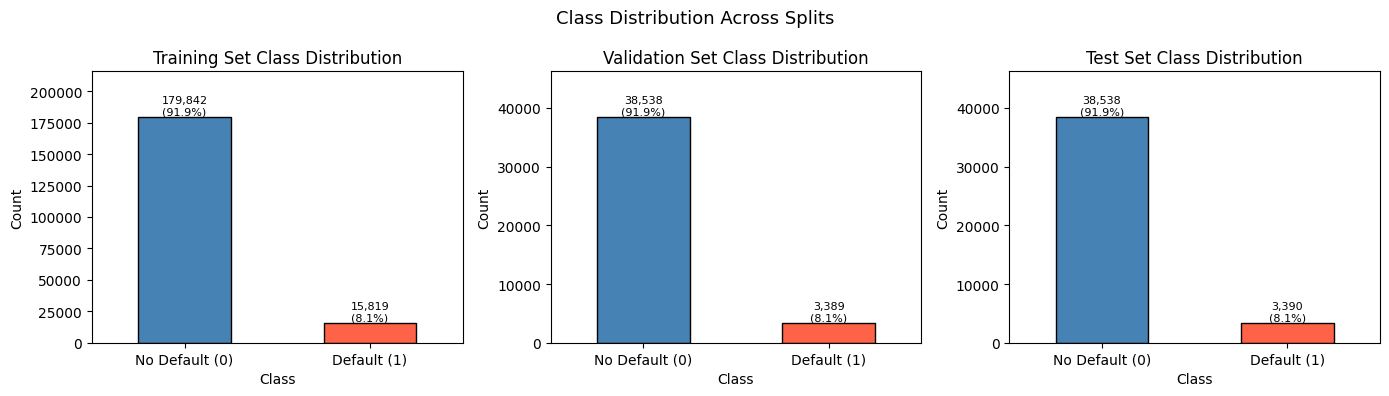

Figure saved: split_distribution.png


In [14]:
# plot of split
# bar graphs generated by claude

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datasets = [
    (y_train, 'Training Set Class Distribution'),
    (y_val,   'Validation Set Class Distribution'),
    (y_test,  'Test Set Class Distribution'),
]

for ax, (y, title) in zip(axes, datasets):
    counts = y.value_counts().sort_index()
    counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
    ax.set_ylim(0, counts.max() * 1.2)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(y)*100:.1f}%)',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Class Distribution Across Splits', fontsize=13)
plt.tight_layout()
plt.savefig('split_distribution.png', dpi=150)
plt.show()
print('Figure saved: split_distribution.png')

### Data Cleaning (Continued)

In [15]:
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

continuous_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

Inconsistent Values:

In [16]:
X_train.describe()

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,195661.000000,1.956610e+05,1.956610e+05,195651.000000,1.954880e+05,195660.000000,195660.000000,195660.000000,195660.000000,195660.000000,...,195660.000000,195660.000000,195660.000000,195660.000000,169175.000000,169175.000000,169175.000000,169175.000000,169175.000000,169175.000000
mean,0.415975,1.691516e+05,5.997583e+05,27124.028543,5.390515e+05,0.020870,-16030.703711,63764.348283,-4986.267346,-2994.121348,...,0.008172,0.000567,0.000486,0.000302,0.006272,0.006987,0.034042,0.266446,0.265908,1.896935
std,0.719651,2.876979e+05,4.030007e+05,14550.671078,3.700333e+05,0.013828,4370.418877,141231.670269,3526.439248,1509.502721,...,0.090031,0.023812,0.022030,0.017362,0.083600,0.112727,0.203109,0.909749,0.880687,1.870263
min,0.000000,2.565000e+04,4.500000e+04,1980.000000,4.500000e+04,0.000290,-25229.000000,-17546.000000,-24672.000000,-7197.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.125000e+05,2.700000e+05,16519.500000,2.385000e+05,0.010006,-19688.000000,-2755.000000,-7473.000000,-4299.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.462500e+05,5.172660e+05,24903.000000,4.500000e+05,0.018850,-15744.000000,-1211.000000,-4497.000000,-3256.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12398.000000,-289.000000,-2009.000000,-1715.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,23.000000


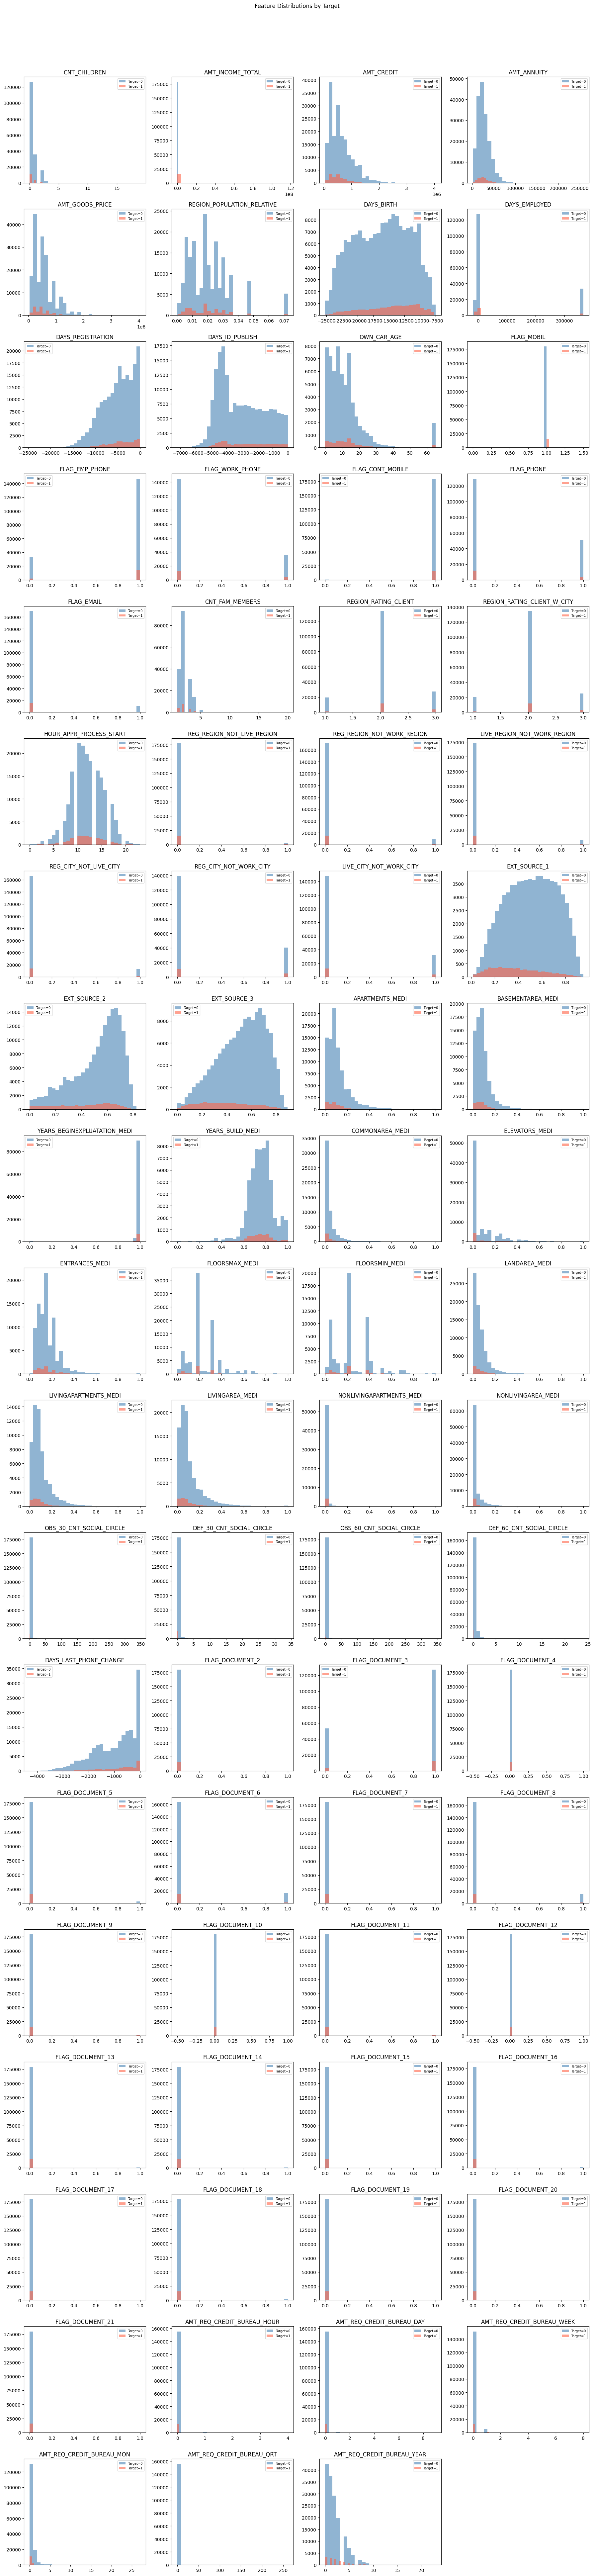

Figure saved: feature_dist_target.png


In [17]:
# graphs generated by claude

# add target back temporarily for plotting
X_train_plot = X_train.copy()
X_train_plot['TARGET'] = y_train.values

n_cols = 4
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        axes[i].hist(X_train_plot[X_train_plot['TARGET'] == label][col].dropna(),
                     bins=30, alpha=0.6, color=color, label=f'Target={label}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Target', y=1.02)
plt.tight_layout()
plt.savefig('feature_dist_target.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: feature_dist_target.png')

In [18]:
# check that there are not negative income, # of children, # family members
non_neg = ['AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']

for col in non_neg:
  if (X_train[col] < 0).any():
    print(f"{col} has negative values")

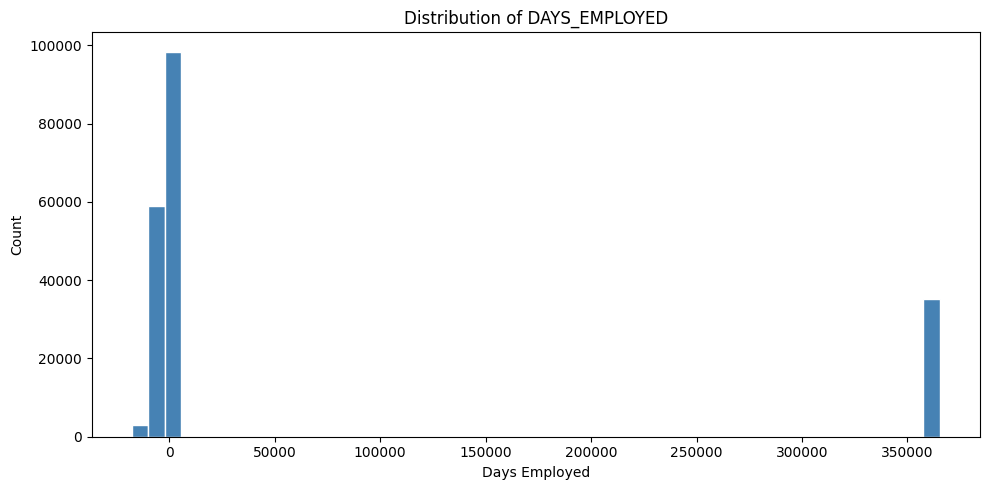

In [19]:
# max value for days employed seems off
# graph generated by claude

plt.figure(figsize=(10, 5))
plt.hist(X_train['DAYS_EMPLOYED'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of DAYS_EMPLOYED')
plt.xlabel('Days Employed')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('day_employed_outlier.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# remove outlier value
X_train['DAYS_EMPLOYED'] = X_train['DAYS_EMPLOYED'].replace(365243, np.nan)
X_val['DAYS_EMPLOYED']   = X_val['DAYS_EMPLOYED'].replace(365243, np.nan)
X_test['DAYS_EMPLOYED']  = X_test['DAYS_EMPLOYED'].replace(365243, np.nan)

Imputation for Missing Values

In [21]:
# most numerical columns are skewed
num_imputer = SimpleImputer(strategy='median')
# mode makes more sense for categories
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[continuous_cols] = num_imputer.fit_transform(X_train[continuous_cols])
X_val[continuous_cols]   = num_imputer.transform(X_val[continuous_cols])
X_test[continuous_cols]  = num_imputer.transform(X_test[continuous_cols])

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_val[categorical_cols]   = cat_imputer.transform(X_val[categorical_cols])
X_test[categorical_cols]  = cat_imputer.transform(X_test[categorical_cols])

print("Imputation done.")

Imputation done.


### Feature Engineering

New Features:

In [22]:
def age_cat(age):
  if age < 30:
    return 'Young'
  elif age < 45:
    return 'Middle'
  elif age < 60:
    return 'Senior'
  else:
    return 'Elder'

In [23]:
def dependants(count):
  if count == 0:
    return 'None'
  elif count < 3:
    return 'Low'
  else:
    return 'High'

In [24]:
for df_ in [X_train, X_val, X_test]:

    ## ratios

    # credit income
    df_['CREDIT_INCOME_PERCENT'] = df_['AMT_CREDIT'] / df_['AMT_INCOME_TOTAL']

    # annuity income
    df_['ANNUITY_INCOME_PERCENT'] = df_['AMT_ANNUITY'] / df_['AMT_INCOME_TOTAL']

    # payment rate
    df_["PAYMENT_RATE"] = (df_["AMT_ANNUITY"] / df_["AMT_CREDIT"])

    # employment to age
    df_['DAYS_EMPLOYED_PERCENT'] = df_['DAYS_EMPLOYED'] / df_['DAYS_BIRTH']

    ## age groups

    df_['AGE_YEARS'] = -df_['DAYS_BIRTH'] / 365

    df_["AGE_GROUP"] = df_["AGE_YEARS"].apply(age_cat)

    ## income / spending

    # dependants
    df_["DEPENDANTS"] = df_["CNT_CHILDREN"].apply(dependants)

    # external source mean score
    df_['EXT_SOURCE_MEAN'] = df_[['EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)


One Hot Encoding for Categorical Variables:

In [25]:
conv_one_hot = categorical_cols + ['AGE_GROUP', 'DEPENDANTS']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_train = ohe.fit_transform(X_train[conv_one_hot])

encoded_val  = ohe.transform(X_val[conv_one_hot])
encoded_test = ohe.transform(X_test[conv_one_hot])

encoded_cols = ohe.get_feature_names_out(conv_one_hot)

encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
encoded_val_df   = pd.DataFrame(encoded_val,   columns=encoded_cols, index=X_val.index)
encoded_test_df  = pd.DataFrame(encoded_test,  columns=encoded_cols, index=X_test.index)

X_train = X_train.drop(columns=conv_one_hot).join(encoded_train_df)
X_val   = X_val.drop(columns=conv_one_hot).join(encoded_val_df)
X_test  = X_test.drop(columns=conv_one_hot).join(encoded_test_df)

print('One-hot categories:', ohe.categories_)
print('Shape after encoding:', X_train.shape)
print('New columns:', list(encoded_cols))
X_train.head()

One-hot categories: [array(['Cash loans', 'Revolving loans'], dtype=object), array(['F', 'M', 'XNA'], dtype=object), array(['N', 'Y'], dtype=object), array(['N', 'Y'], dtype=object), array(['Children', 'Family', 'Group of people', 'Other_A', 'Other_B',
       'Spouse, partner', 'Unaccompanied'], dtype=object), array(['Businessman', 'Commercial associate', 'Maternity leave',
       'Pensioner', 'State servant', 'Student', 'Unemployed', 'Working'],
      dtype=object), array(['Academic degree', 'Higher education', 'Incomplete higher',
       'Lower secondary', 'Secondary / secondary special'], dtype=object), array(['Civil marriage', 'Married', 'Separated', 'Single / not married',
       'Unknown', 'Widow'], dtype=object), array(['Co-op apartment', 'House / apartment', 'Municipal apartment',
       'Office apartment', 'Rented apartment', 'With parents'],
      dtype=object), array(['Accountants', 'Cleaning staff', 'Cooking staff', 'Core staff',
       'Drivers', 'HR staff', 'High skill te

,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA,AGE_GROUP_Elder,AGE_GROUP_Middle,AGE_GROUP_Senior,AGE_GROUP_Young,DEPENDANTS_High,DEPENDANTS_Low,DEPENDANTS_None
69245,1.0,225000.0,180000.0,9000.0,180000.0,0.024610,-9164.0,-565.0,-1561.0,-1838.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
273748,1.0,202500.0,1350000.0,39604.5,1350000.0,0.011703,-18122.0,-9949.0,-4267.0,-1651.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
139112,1.0,157500.0,490495.5,47911.5,454500.0,0.015221,-14406.0,-3641.0,-2602.0,-2686.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
173070,0.0,225000.0,142200.0,8293.5,112500.0,0.031329,-20656.0,-1644.0,-3509.0,-4138.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208112,0.0,189000.0,276277.5,11835.0,238500.0,0.018029,-23598.0,-13421.0,-14938.0,-4572.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### GDBT

In [26]:
pos_label = 1
class_names = ['No Default', 'Default']
feature_names = np.array(X_train.columns)

In [27]:
# handle class imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {pos_weight:.2f}")

scale_pos_weight: 11.37


Baseline Model

In [28]:
# code adapted from AML_L5_Colab_Demos.ipynb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=6,
    learning_rate=0.10,
    n_estimators=500,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    gamma=0.0,
    scale_pos_weight=pos_weight,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

start = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

xgb_train_time = time.time() - start
print(f"XGBoost training time: {xgb_train_time:.2f}s")

[0]	validation_0-logloss:0.67767	validation_1-logloss:0.67770
[100]	validation_0-logloss:0.52774	validation_1-logloss:0.54470
[200]	validation_0-logloss:0.49084	validation_1-logloss:0.51962
[300]	validation_0-logloss:0.45859	validation_1-logloss:0.49815
[400]	validation_0-logloss:0.43065	validation_1-logloss:0.48067
[499]	validation_0-logloss:0.40414	validation_1-logloss:0.46416
XGBoost training time: 81.84s


Visualize:

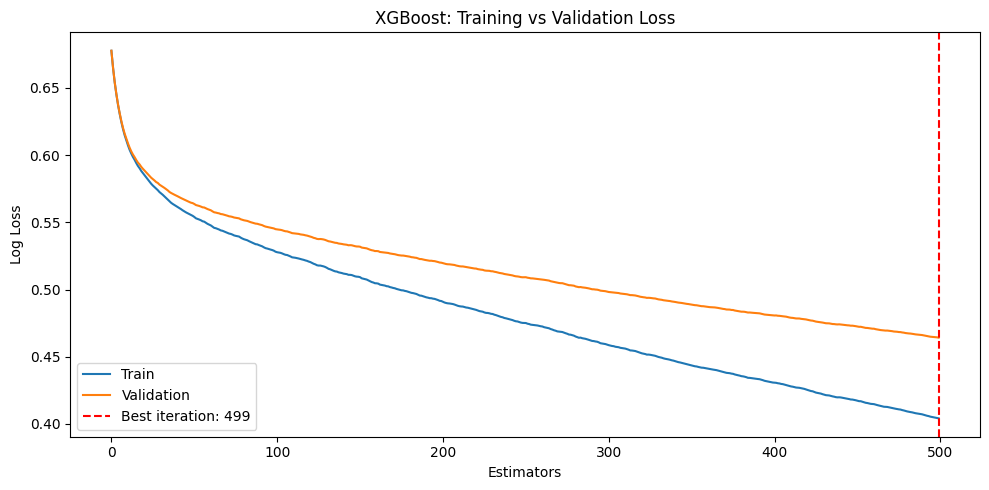

In [29]:
# training vs validation loss curve
results_curve = xgb_model.evals_result()
epochs = len(results_curve['validation_0']['logloss'])

plt.figure(figsize=(10, 5))
plt.plot(results_curve['validation_0']['logloss'], label='Train')
plt.plot(results_curve['validation_1']['logloss'], label='Validation')
plt.axvline(xgb_model.best_iteration, color='red', linestyle='--',
            label=f'Best iteration: {xgb_model.best_iteration}')
plt.title('XGBoost: Training vs Validation Loss')
plt.xlabel('Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_loss_curve.png', dpi=150)
plt.show()

In [30]:
# predict and evaluate
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, pos_label=pos_label)

print(f"Accuracy: {acc:.4f} | F1: {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

Accuracy: 0.7795 | F1: 0.2887
              precision    recall  f1-score   support

  No Default      0.953     0.799     0.870     38538
     Default      0.195     0.553     0.289      3390

    accuracy                          0.780     41928
   macro avg      0.574     0.676     0.579     41928
weighted avg      0.892     0.780     0.823     41928



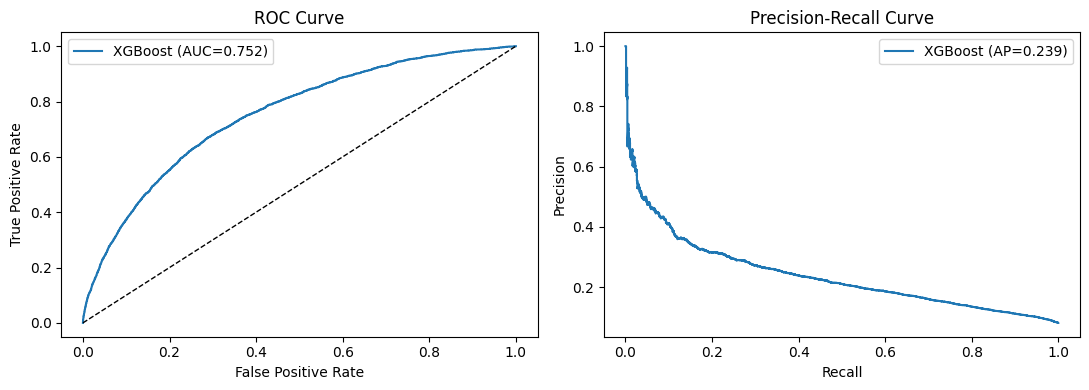

In [31]:
# ROC and PC curves
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=pos_label)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'XGBoost (AUC={roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
prec, rec, _ = precision_recall_curve(y_test, y_proba, pos_label=pos_label)
ap = average_precision_score(y_test, y_proba, pos_label=pos_label)
plt.plot(rec, prec, label=f'XGBoost (AP={ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.savefig('xgb_roc_pr.png', dpi=150)
plt.show()

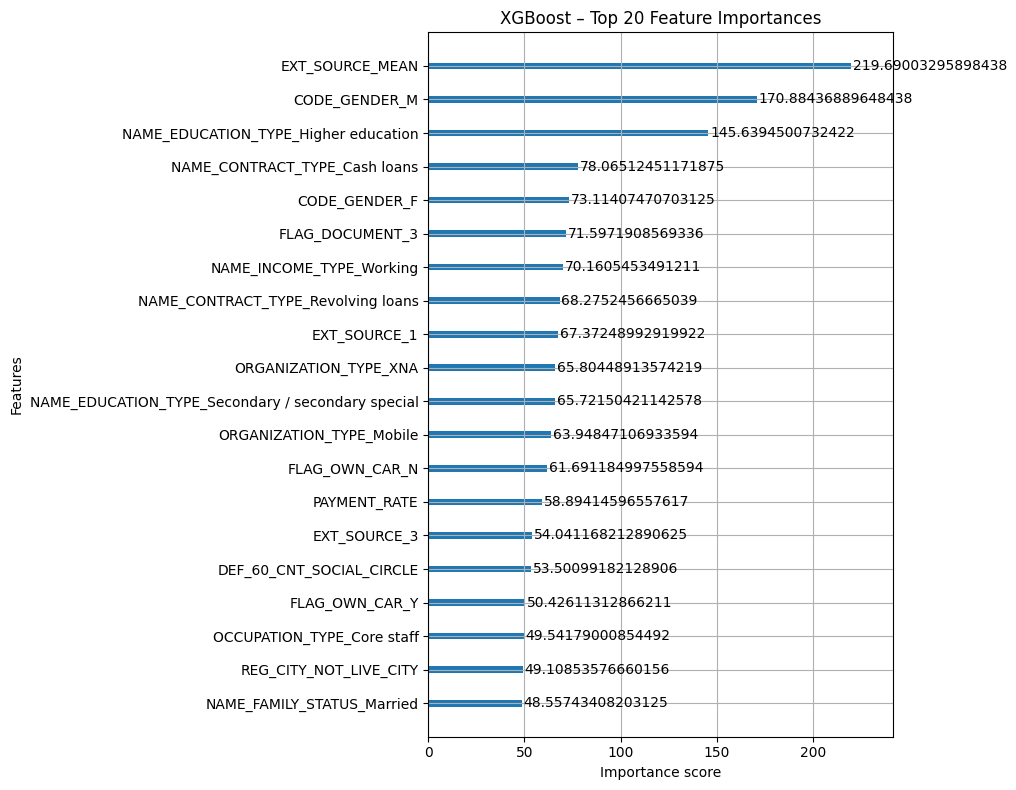

In [32]:
# Create the plot using XGBoost's built-in function
fig, ax = plt.subplots(figsize=(10, 8))

# max_num_features controls the 'top 20'
# importance_type can be 'weight', 'gain', or 'cover'
plot_importance(xgb_model, ax=ax, max_num_features=20, importance_type='gain')

plt.title('XGBoost – Top 20 Feature Importances')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

LR=0.01 | Best iter: 499 | Val AP: 0.2533
LR=0.1 | Best iter: 499 | Val AP: 0.2435
LR=0.3 | Best iter: 499 | Val AP: 0.2114


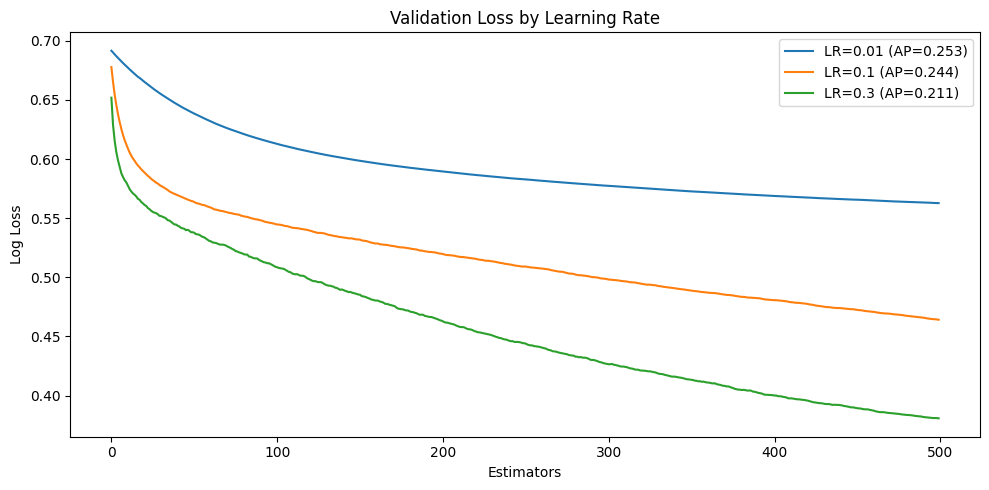

In [33]:
# learning rate comparison
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

plt.figure(figsize=(10, 5))

for lr in learning_rates:
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=6,
        learning_rate=lr,
        n_estimators=500,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        scale_pos_weight=pos_weight,
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    val_proba = model.predict_proba(X_val)[:, 1]
    val_ap    = average_precision_score(y_val, val_proba)
    lr_results[lr] = {'model': model, 'val_ap': val_ap}

    val_curve = model.evals_result()['validation_1']['logloss']
    plt.plot(val_curve, label=f'LR={lr} (AP={val_ap:.3f})')
    print(f"LR={lr} | Best iter: {model.best_iteration} | Val AP: {val_ap:.4f}")

plt.title('Validation Loss by Learning Rate')
plt.xlabel('Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_lr_comparison.png', dpi=150)
plt.show()

### MLP

Feature Scaling

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# convert to float32
X_train_scaled = X_train_scaled.astype(np.float32)
X_val_scaled   = X_val_scaled.astype(np.float32)
X_test_scaled  = X_test_scaled.astype(np.float32)

print("Scaling done.")

Scaling done.


Base Model:

In [35]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)

start = time.time()
mlp_baseline.fit(X_train_scaled, y_train)

mlp_train_time = time.time() - start
print(f"MLP training time: {mlp_train_time:.2f}s")

Iteration 1, loss = 0.26289206
Validation score: 0.919047
Iteration 2, loss = 0.24932438
Validation score: 0.919252
Iteration 3, loss = 0.24515845
Validation score: 0.918996
Iteration 4, loss = 0.24190612
Validation score: 0.918230
Iteration 5, loss = 0.23799637
Validation score: 0.917565
Iteration 6, loss = 0.23393407
Validation score: 0.917821
Iteration 7, loss = 0.22926876
Validation score: 0.916901
Iteration 8, loss = 0.22482291
Validation score: 0.916901
Iteration 9, loss = 0.21914880
Validation score: 0.915214
Iteration 10, loss = 0.21411965
Validation score: 0.915777
Iteration 11, loss = 0.20924958
Validation score: 0.912148
Iteration 12, loss = 0.20423569
Validation score: 0.913375
Iteration 13, loss = 0.20002816
Validation score: 0.908928
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
MLP training time: 38.29s


Visualize:

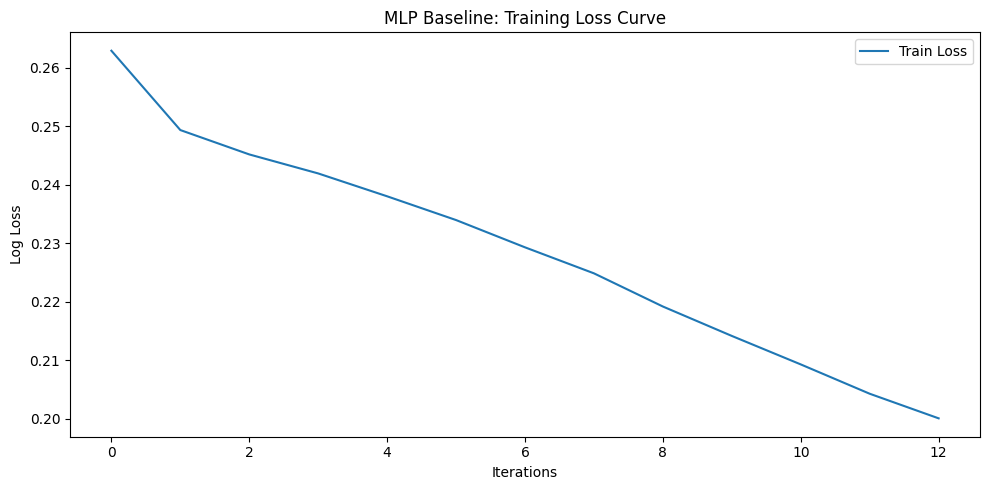

In [36]:
# training vs validation loss curve
plt.figure(figsize=(10, 5))
plt.plot(mlp_baseline.loss_curve_, label='Train Loss')
if mlp_baseline.best_loss_ is not None:
    plt.axhline(mlp_baseline.best_loss_, color='red', linestyle='--',
                label=f'Best Loss: {mlp_baseline.best_loss_:.4f}')
plt.title('MLP Baseline: Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_baseline_curve.png', dpi=150)
plt.show()

In [37]:
y_pred_mlp  = mlp_baseline.predict(X_test_scaled)
y_proba_mlp = mlp_baseline.predict_proba(X_test_scaled)[:, 1]

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp  = f1_score(y_test, y_pred_mlp, pos_label=pos_label)

print(f"\n=== MLP Baseline ===")
print(f"Accuracy: {acc_mlp:.4f} | F1: {f1_mlp:.4f}")
print(classification_report(y_test, y_pred_mlp, target_names=class_names, digits=3))


=== MLP Baseline ===
Accuracy: 0.9194 | F1: 0.0117
              precision    recall  f1-score   support

  No Default      0.920     1.000     0.958     38538
     Default      0.645     0.006     0.012      3390

    accuracy                          0.919     41928
   macro avg      0.782     0.503     0.485     41928
weighted avg      0.897     0.919     0.881     41928



Shallow (64,) | Iterations: 17 | Val AP: 0.2189
Medium (128, 64) | Iterations: 13 | Val AP: 0.2208
Deep (256, 128, 64) | Iterations: 14 | Val AP: 0.2245


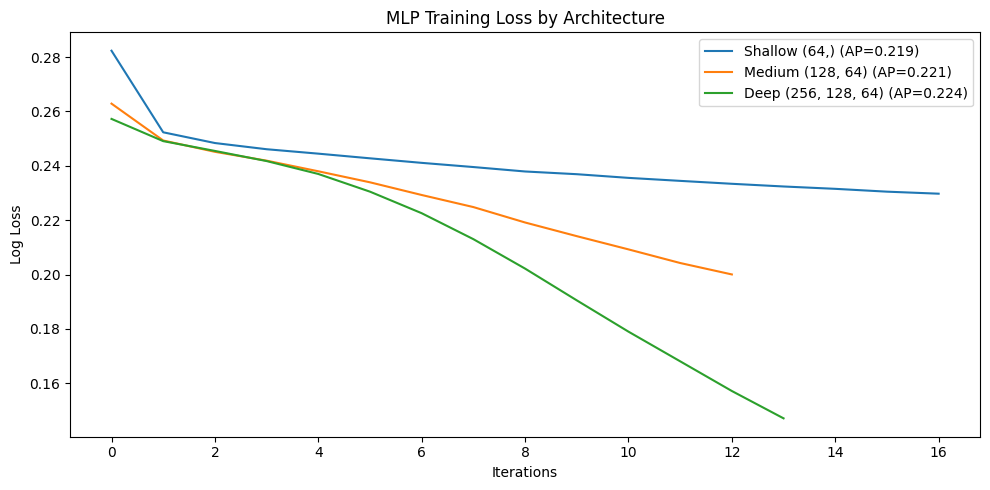

In [38]:
architectures = {
    'Shallow (64,)':         (64,),
    'Medium (128, 64)':      (128, 64),
    'Deep (256, 128, 64)':   (256, 128, 64),
}

arch_results = {}
plt.figure(figsize=(10, 5))

for name, layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    val_ap    = average_precision_score(y_val, val_proba)
    arch_results[name] = {'model': model, 'val_ap': val_ap}

    plt.plot(model.loss_curve_, label=f'{name} (AP={val_ap:.3f})')
    print(f"{name} | Iterations: {model.n_iter_} | Val AP: {val_ap:.4f}")

plt.title('MLP Training Loss by Architecture')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_arch_comparison.png', dpi=150)
plt.show()

LR=0.001 | Iterations: 13 | Val AP: 0.2208
LR=0.01 | Iterations: 12 | Val AP: 0.2254
LR=0.1 | Iterations: 13 | Val AP: 0.0808


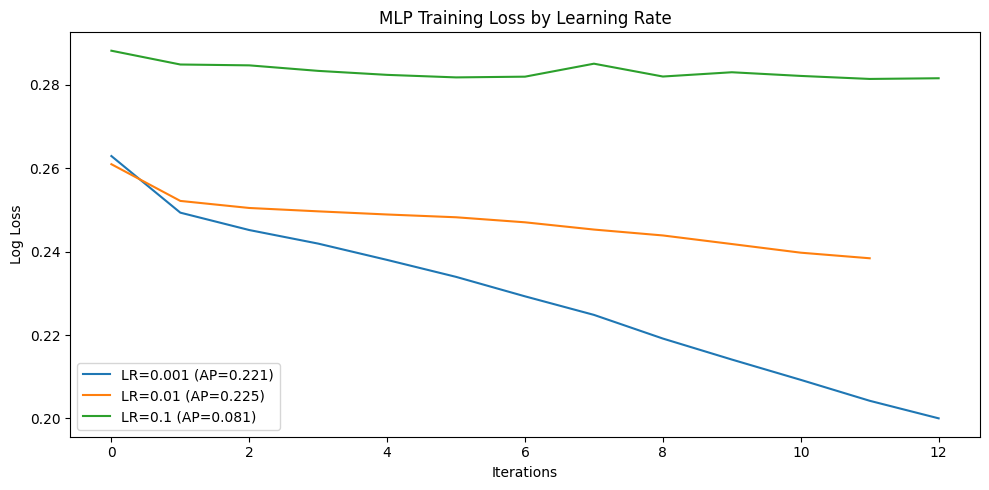

In [39]:
learning_rates_mlp = [0.001, 0.01, 0.1]
lr_mlp_results = {}

plt.figure(figsize=(10, 5))

for lr in learning_rates_mlp:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=lr,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    val_ap    = average_precision_score(y_val, val_proba)
    lr_mlp_results[lr] = {'model': model, 'val_ap': val_ap}

    plt.plot(model.loss_curve_, label=f'LR={lr} (AP={val_ap:.3f})')
    print(f"LR={lr} | Iterations: {model.n_iter_} | Val AP: {val_ap:.4f}")

plt.title('MLP Training Loss by Learning Rate')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_lr_comparison.png', dpi=150)
plt.show()

In [40]:
activations = ['relu', 'tanh']
act_results = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation=act,
        learning_rate_init=0.001,
        max_iter=100,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    val_proba = model.predict_proba(X_val_scaled)[:, 1]
    val_ap    = average_precision_score(y_val, val_proba)
    act_results[act] = {'model': model, 'val_ap': val_ap}
    print(f"Activation={act} | Val AP: {val_ap:.4f}")

Activation=relu | Val AP: 0.2208
Activation=tanh | Val AP: 0.2077


### Compare

In [41]:
# retrieve computed values

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_pred_mlp  = mlp_baseline.predict(X_test_scaled)
y_proba_mlp = mlp_baseline.predict_proba(X_test_scaled)[:, 1]

In [42]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'F1-Score':  f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'AUC-PR':    average_precision_score(y_true, y_proba)
    }

xgb_metrics = get_metrics(y_test, y_pred_xgb, y_proba_xgb)
mlp_metrics = get_metrics(y_test, y_pred_mlp, y_proba_mlp)


=== Model Comparison ===
               XGBoost      MLP
Accuracy        0.7795   0.9194
Precision       0.1953   0.6452
Recall          0.5534   0.0059
F1-Score        0.2887   0.0117
AUC-PR          0.2388   0.2127
Training Time  81.8435  38.2856


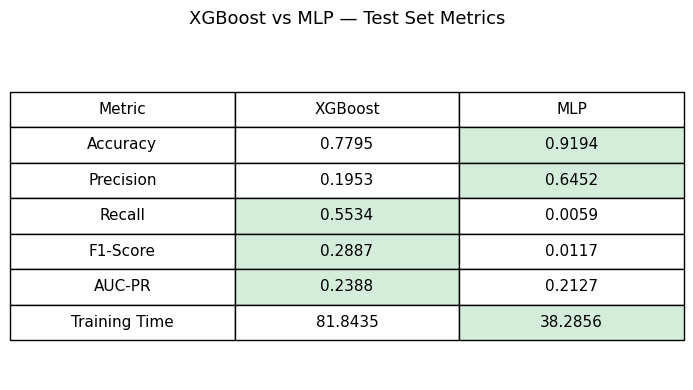

In [43]:
comparison_df = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'MLP':     mlp_metrics
}).round(4)

# Create a Series for training times
training_times_s = pd.Series({
    'XGBoost': round(xgb_train_time, 4),
    'MLP':     round(mlp_train_time, 4)
}, name='Training Time')

# Add the training times as a new row to the comparison_df
comparison_df = pd.concat([comparison_df, pd.DataFrame(training_times_s).T])

print("=== Model Comparison ===")
print(comparison_df.to_string())

# styled heatmap table
fig, ax = plt.subplots(figsize=(7, 4)) # Adjusted figure height for the new row
ax.axis('off')
table = ax.table(
    cellText=comparison_df.reset_index().values,
    colLabels=['Metric', 'XGBoost', 'MLP'],
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# highlight better value per row
for i in range(len(comparison_df)):
    xgb_val = comparison_df.iloc[i]['XGBoost']
    mlp_val = comparison_df.iloc[i]['MLP']

    if comparison_df.index[i] == 'Training Time':
        better_col = 1 if xgb_val <= mlp_val else 2 # Lower time is better
    else:
        better_col = 1 if xgb_val >= mlp_val else 2 # Higher metric is better

    table[i+1, better_col].set_facecolor('#d4edda')  # green highlight

plt.title('XGBoost vs MLP — Test Set Metrics', pad=20, fontsize=13)
plt.tight_layout()
plt.savefig('comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

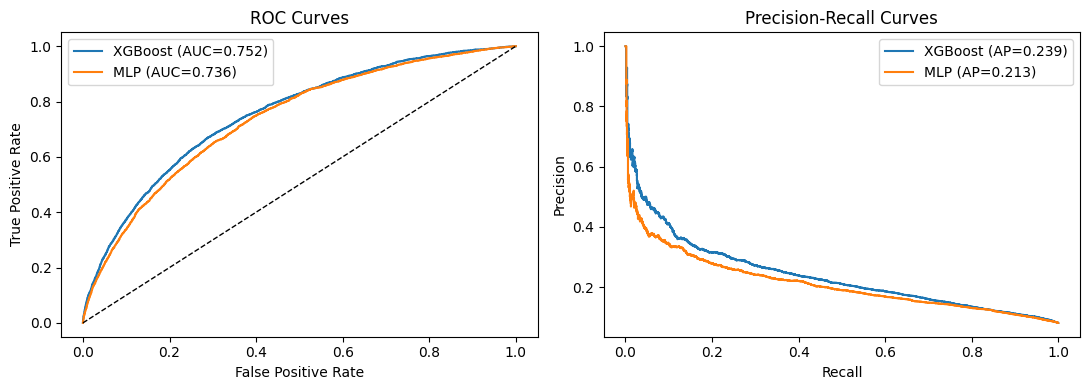

In [44]:
plt.figure(figsize=(11, 4))

# ROC
plt.subplot(1, 2, 1)
for name, y_proba in [('XGBoost', y_proba_xgb), ('MLP', y_proba_mlp)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()

# PR
plt.subplot(1, 2, 2)
for name, y_proba in [('XGBoost', y_proba_xgb), ('MLP', y_proba_mlp)]:
    prec, rec, _ = precision_recall_curve(y_test, y_proba, pos_label=1)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()

plt.tight_layout()
plt.savefig('comparison_roc_pr.png', dpi=150)
plt.show()


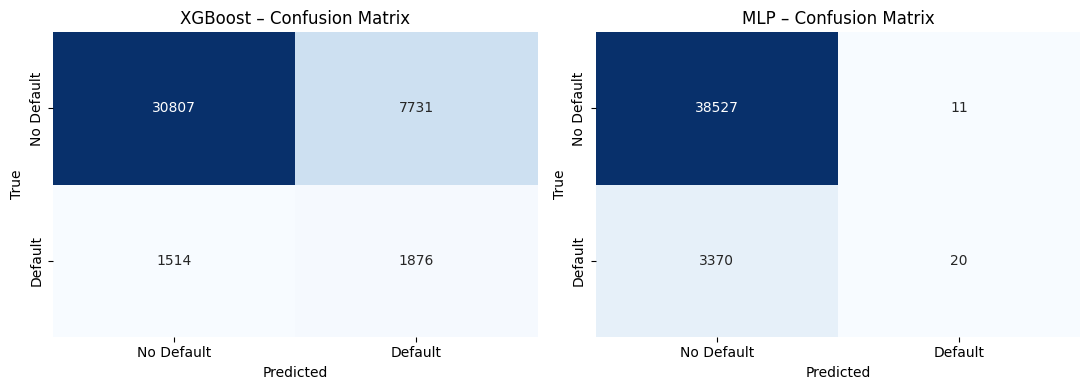

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, name in zip(axes,
                             [y_pred_xgb, y_pred_mlp],
                             ['XGBoost', 'MLP']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{name} – Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('comparison_confusion.png', dpi=150)
plt.show()